# Classical ML Baselines For Congestion Prediction
This notebook trains and evaluates four non-graph baselines for multi-label congestion prediction: logistic regression, random forest, XGBoost, and a multilayer perceptron (MLP).

Each sample predicts congestion across the 80 transmission lines, so the task is treated as multi-label binary classification. The notebook loads the tabular congestion dataset, splits it into train, validation, and test sets, tunes a single decision threshold per model on the validation set, and reports final metrics on the test set.

In [1]:
import importlib.util
import subprocess
import sys

required_packages = [
    "pandas>=2.2.3",
    "numpy",
    "scikit-learn",
    "matplotlib",
    "joblib",
    "xgboost",
]

if importlib.util.find_spec("pip") is None:
    raise RuntimeError(
        "pip is not available in this notebook kernel. Select the project virtual environment kernel before running this notebook."
    )

subprocess.check_call([sys.executable, "-m", "pip", "install", "--no-cache-dir", "-q", *required_packages])

0

In [2]:
import os
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, hamming_loss, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

def ensure_project_root():
    candidate_roots = [
        Path.cwd(),
        Path.cwd() / "nodal-gnn",
        Path(r"c:\Users\i34005\OneDrive - Wood Mackenzie Limited\CSML\nodal-gnn"),
    ]

    for root in candidate_roots:
        if (root / "congestion_dataset_v5.csv").exists() or (root / "congestion_dataset_v5.7z").exists():
            if str(root) not in sys.path:
                sys.path.insert(0, str(root))
            os.chdir(root)
            return root

    checked = "\n".join(str(path) for path in candidate_roots)
    raise FileNotFoundError(f"Unable to locate the nodal-gnn project folder. Checked:\n{checked}")

project_root = ensure_project_root()
results_dir = project_root / "results" / "classical_ml_baselines"
results_dir.mkdir(parents=True, exist_ok=True)

print(f"Using project root: {project_root}")
print(f"Saving outputs to: {results_dir}")

Using project root: c:\Users\i34005\OneDrive - Wood Mackenzie Limited\CSML\nodal-gnn
Saving outputs to: c:\Users\i34005\OneDrive - Wood Mackenzie Limited\CSML\nodal-gnn\results\classical_ml_baselines


In [3]:
DATASET_NAME = "congestion_dataset_v5.csv"
RANDOM_SEED = 42
VALIDATION_SIZE = 0.15
TEST_SIZE = 0.15
MAX_SAMPLES = 50000  # set to None to use the full CSV
THRESHOLD_GRID = np.array([0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 0.975, 0.99])
SAVE_MODELS = True

def resolve_csv_path():
    candidates = [
        os.environ.get("CONGESTION_DATASET_PATH"),
        str(project_root / DATASET_NAME),
    ]

    for candidate in candidates:
        if candidate and Path(candidate).exists():
            return Path(candidate)

    checked = "\n".join(path for path in candidates if path)
    raise FileNotFoundError(f"Unable to locate {DATASET_NAME}. Checked:\n{checked}")

csv_path = resolve_csv_path()
print(f"Using dataset CSV: {csv_path}")

Using dataset CSV: c:\Users\i34005\OneDrive - Wood Mackenzie Limited\CSML\nodal-gnn\congestion_dataset_v5.csv


In [4]:
if MAX_SAMPLES is None:
    df = pd.read_csv(csv_path)
else:
    df = pd.read_csv(csv_path, nrows=int(MAX_SAMPLES))

feature_columns = list(df.columns[:171])
target_columns = list(df.columns[171:])

X = df[feature_columns].astype(np.float32)
y = df[target_columns].astype(np.int32)

positive_rate_per_line = y.mean(axis=0)
positive_labels_per_sample = y.sum(axis=1)

print(f"Samples loaded: {len(df):,}")
print(f"Feature columns: {len(feature_columns)}")
print(f"Target columns: {len(target_columns)}")
print(f"Average congested lines per sample: {positive_labels_per_sample.mean():.4f}")
print(f"Median congested lines per sample: {positive_labels_per_sample.median():.4f}")
print(f"Samples with any congestion: {(positive_labels_per_sample > 0).mean():.4%}")
print(f"Mean per-line congestion rate: {positive_rate_per_line.mean():.4%}")

dataset_summary = pd.DataFrame({
    "metric": [
        "samples",
        "features",
        "targets",
        "samples_with_any_congestion",
        "avg_congested_lines_per_sample",
        "mean_line_congestion_rate",
    ],
    "value": [
        len(df),
        len(feature_columns),
        len(target_columns),
        float((positive_labels_per_sample > 0).mean()),
        float(positive_labels_per_sample.mean()),
        float(positive_rate_per_line.mean()),
    ],
})
display(dataset_summary)

Samples loaded: 50,000
Feature columns: 171
Target columns: 80
Average congested lines per sample: 0.0838
Median congested lines per sample: 0.0000
Samples with any congestion: 7.7000%
Mean per-line congestion rate: 0.1047%


,metric,value
0,samples,50000.000000
1,features,171.000000
2,targets,80.000000
3,samples_with_any_congestion,0.077000
4,avg_congested_lines_per_sample,0.083760
5,mean_line_congestion_rate,0.001047


In [5]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, shuffle=True
)

relative_val_size = VALIDATION_SIZE / (1.0 - TEST_SIZE)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=relative_val_size,
    random_state=RANDOM_SEED,
    shuffle=True,
)

split_summary = pd.DataFrame({
    "split": ["train", "val", "test"],
    "rows": [len(X_train), len(X_val), len(X_test)],
    "samples_with_any_congestion": [
        float((y_train.sum(axis=1) > 0).mean()),
        float((y_val.sum(axis=1) > 0).mean()),
        float((y_test.sum(axis=1) > 0).mean()),
    ],
    "avg_congested_lines_per_sample": [
        float(y_train.sum(axis=1).mean()),
        float(y_val.sum(axis=1).mean()),
        float(y_test.sum(axis=1).mean()),
    ],
})
display(split_summary)

,split,rows,samples_with_any_congestion,avg_congested_lines_per_sample
0,train,34999,0.075688,0.082317
1,val,7501,0.079856,0.087188
2,test,7500,0.080267,0.087067


In [6]:
class ConstantAwareMultiLabelLogistic(BaseEstimator, ClassifierMixin):
    def __init__(self, base_estimator, scaler=None):
        self.base_estimator = base_estimator
        self.scaler = scaler if scaler is not None else StandardScaler()

    def fit(self, X, y):
        X_values = X.to_numpy(dtype=np.float32, copy=False) if hasattr(X, "to_numpy") else np.asarray(X, dtype=np.float32)
        y_values = y.to_numpy(dtype=np.int32, copy=False) if hasattr(y, "to_numpy") else np.asarray(y, dtype=np.int32)

        self.scaler_ = clone(self.scaler)
        X_scaled = self.scaler_.fit_transform(X_values)
        self.estimators_ = []
        self.constant_targets_ = []

        for column_idx in range(y_values.shape[1]):
            target = y_values[:, column_idx]
            unique_values = np.unique(target)
            if unique_values.size < 2:
                self.estimators_.append(None)
                self.constant_targets_.append(int(unique_values[0]))
                continue

            estimator = clone(self.base_estimator)
            estimator.fit(X_scaled, target)
            self.estimators_.append(estimator)
            self.constant_targets_.append(None)

        self.n_outputs_ = y_values.shape[1]
        return self

    def predict_proba(self, X):
        X_values = X.to_numpy(dtype=np.float32, copy=False) if hasattr(X, "to_numpy") else np.asarray(X, dtype=np.float32)
        X_scaled = self.scaler_.transform(X_values)
        probabilities = []

        for estimator, constant_value in zip(self.estimators_, self.constant_targets_):
            if estimator is None:
                positive_probability = np.full(X_scaled.shape[0], float(constant_value), dtype=np.float32)
            else:
                positive_probability = estimator.predict_proba(X_scaled)[:, 1].astype(np.float32)
            probabilities.append(positive_probability)

        return np.column_stack(probabilities)

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(np.int32)

numeric_preprocessor = ColumnTransformer(
    transformers=[("num", StandardScaler(), feature_columns)],
    remainder="drop",
)

baseline_models = {
    "LogisticRegression": ConstantAwareMultiLabelLogistic(
        base_estimator=LogisticRegression(
            solver="saga",
            class_weight="balanced",
            max_iter=1000,
            random_state=RANDOM_SEED,
        ),
        scaler=StandardScaler(),
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=400,
        max_depth=18,
        min_samples_leaf=5,
        max_features="sqrt",
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=RANDOM_SEED,
    ),
    "XGBoost": MultiOutputClassifier(
        XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            n_estimators=300,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            tree_method="hist",
            random_state=RANDOM_SEED,
            n_jobs=-1,
        ),
        n_jobs=-1,
    ),
    "MLP": Pipeline(
        steps=[
            ("preprocess", numeric_preprocessor),
            ("model", MLPClassifier(
                hidden_layer_sizes=(256, 128),
                activation="relu",
                learning_rate_init=1e-3,
                alpha=1e-4,
                batch_size=256,
                max_iter=100,
                early_stopping=True,
                validation_fraction=0.1,
                random_state=RANDOM_SEED,
            )),
        ]
    ),
}

list(baseline_models.keys())

['LogisticRegression', 'RandomForest', 'XGBoost', 'MLP']

In [7]:
def get_probability_scores(model, X_input):
    estimator = model
    transformed_input = X_input

    if hasattr(model, "named_steps") and "preprocess" in model.named_steps and "model" in model.named_steps:
        transformed_input = model.named_steps["preprocess"].transform(X_input)
        estimator = model.named_steps["model"]

    raw = estimator.predict_proba(transformed_input)

    if isinstance(raw, list):
        estimator_classes = getattr(estimator, "classes_", None)
        probabilities = []

        for output_idx, item in enumerate(raw):
            item = np.asarray(item)
            output_classes = None

            if isinstance(estimator_classes, list) and output_idx < len(estimator_classes):
                output_classes = np.asarray(estimator_classes[output_idx])
            elif estimator_classes is not None and not isinstance(estimator_classes, list):
                output_classes = np.asarray(estimator_classes)

            if item.ndim == 2 and item.shape[1] == 2:
                positive_column = 1
                if output_classes is not None and np.any(output_classes == 1):
                    positive_column = int(np.flatnonzero(output_classes == 1)[0])
                probabilities.append(item[:, positive_column].astype(np.float32))
            elif item.ndim == 2 and item.shape[1] == 1:
                positive_probability = np.zeros(item.shape[0], dtype=np.float32)
                if output_classes is not None and output_classes.size == 1 and int(output_classes[0]) == 1:
                    positive_probability.fill(1.0)
                probabilities.append(positive_probability)
            else:
                probabilities.append(item.ravel().astype(np.float32))

        return np.column_stack(probabilities)

    raw = np.asarray(raw)
    if raw.ndim == 3 and raw.shape[-1] == 2:
        return raw[:, :, 1]

    return raw

def compute_metrics(y_true, y_pred):
    test_accuracy = accuracy_score(y_true, y_pred)
    test_precision = precision_score(y_true, y_pred, average="micro", zero_division=0)
    test_recall = recall_score(y_true, y_pred, average="micro", zero_division=0)
    test_f1 = f1_score(y_true, y_pred, average="micro", zero_division=0)

    return {
        "accuracy": test_accuracy,
        "precision": test_precision,
        "recall": test_recall,
        "f1": test_f1,
        "subset_accuracy": test_accuracy,
        "micro_precision": test_precision,
        "micro_recall": test_recall,
        "micro_f1": test_f1,
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "samples_f1": f1_score(y_true, y_pred, average="samples", zero_division=0),
        "hamming_loss": hamming_loss(y_true, y_pred),
        "mean_line_f1": float(np.mean(f1_score(y_true, y_pred, average=None, zero_division=0))),
        "predicted_positive_rate": float(np.mean(y_pred)),
        "true_positive_rate": float(np.mean(y_true)),
    }

def find_best_threshold(y_true, y_scores, threshold_grid):
    threshold_results = []
    for threshold in threshold_grid:
        predictions = (y_scores >= threshold).astype(int)
        threshold_results.append({
            "threshold": float(threshold),
            "f1": f1_score(y_true, predictions, average="micro", zero_division=0),
            "precision": precision_score(y_true, predictions, average="micro", zero_division=0),
            "recall": recall_score(y_true, predictions, average="micro", zero_division=0),
            "macro_f1": f1_score(y_true, predictions, average="macro", zero_division=0),
        })

    threshold_df = pd.DataFrame(threshold_results)
    best_row = threshold_df.sort_values(["f1", "macro_f1"], ascending=False).iloc[0]
    return float(best_row["threshold"]), threshold_df

def find_best_thresholds_per_target(y_true, y_scores, threshold_grid):
    y_true_values = y_true.to_numpy(dtype=np.int32, copy=False) if hasattr(y_true, "to_numpy") else np.asarray(y_true, dtype=np.int32)
    thresholds = np.full(y_scores.shape[1], 0.5, dtype=np.float32)
    rows = []

    for target_idx in range(y_scores.shape[1]):
        target_true = y_true_values[:, target_idx]
        target_scores = y_scores[:, target_idx]
        unique_values = np.unique(target_true)

        if unique_values.size < 2:
            chosen_threshold = 1.0 if int(unique_values[0]) == 0 else 0.0
            thresholds[target_idx] = chosen_threshold
            rows.append({
                "target_index": target_idx,
                "best_threshold": chosen_threshold,
                "f1": 1.0,
                "precision": 1.0,
                "recall": 1.0,
                "positive_rate": float(np.mean(target_true)),
            })
            continue

        best_result = {
            "target_index": target_idx,
            "best_threshold": 0.5,
            "f1": -1.0,
            "precision": 0.0,
            "recall": 0.0,
            "positive_rate": float(np.mean(target_true)),
        }

        for threshold in threshold_grid:
            predictions = (target_scores >= threshold).astype(int)
            candidate = {
                "target_index": target_idx,
                "best_threshold": float(threshold),
                "f1": f1_score(target_true, predictions, zero_division=0),
                "precision": precision_score(target_true, predictions, zero_division=0),
                "recall": recall_score(target_true, predictions, zero_division=0),
                "positive_rate": float(np.mean(target_true)),
            }
            if (candidate["f1"], candidate["precision"], candidate["best_threshold"]) > (best_result["f1"], best_result["precision"], best_result["best_threshold"]):
                best_result = candidate

        thresholds[target_idx] = best_result["best_threshold"]
        rows.append(best_result)

    return thresholds, pd.DataFrame(rows)

In [8]:
fitted_models = {}
threshold_tables = {}
test_predictions = {}
test_probabilities = {}
results_rows = []

for model_name, model in baseline_models.items():
    print(f"\nTraining {model_name}...")
    model.fit(X_train, y_train)
    fitted_models[model_name] = model

    val_scores = get_probability_scores(model, X_val)
    best_threshold, threshold_df = find_best_threshold(y_val, val_scores, THRESHOLD_GRID)
    threshold_tables[model_name] = threshold_df

    decision_threshold = best_threshold
    threshold_strategy = "global"

    if model_name == "RandomForest":
        per_target_thresholds, per_target_threshold_df = find_best_thresholds_per_target(y_val, val_scores, THRESHOLD_GRID)
        decision_threshold = per_target_thresholds
        threshold_strategy = "per_target"
        per_target_threshold_df.to_csv(results_dir / "randomforest_per_target_thresholds.csv", index=False)

    test_scores = get_probability_scores(model, X_test)
    test_pred = (test_scores >= decision_threshold).astype(int)
    test_predictions[model_name] = test_pred
    test_probabilities[model_name] = test_scores

    metrics = compute_metrics(y_test, test_pred)
    metrics.update({
        "model": model_name,
        "best_threshold": float(np.median(np.asarray(decision_threshold, dtype=np.float32))) if np.ndim(decision_threshold) > 0 else float(decision_threshold),
        "threshold_strategy": threshold_strategy,
    })
    results_rows.append(metrics)

    if SAVE_MODELS:
        joblib.dump(model, results_dir / f"{model_name.lower()}_model.joblib")

results_df = pd.DataFrame(results_rows).sort_values("f1", ascending=False).reset_index(drop=True)
results_df.to_csv(results_dir / "baseline_results.csv", index=False)

test_metric_columns = ["model", "accuracy", "precision", "recall", "f1", "best_threshold", "threshold_strategy"]
display(results_df[test_metric_columns])
display(results_df)


Training LogisticRegression...

Training RandomForest...

Training XGBoost...

Training MLP...


,model,accuracy,precision,recall,f1,best_threshold,threshold_strategy
0,XGBoost,0.983733,0.905280,0.892802,0.898998,0.35,global
1,MLP,0.981467,0.901899,0.872894,0.887160,0.35,global
2,LogisticRegression,0.964133,0.741977,0.885145,0.807263,0.85,global
3,RandomForest,0.959733,0.723347,0.820827,0.769010,1.00,per_target


,accuracy,precision,recall,f1,subset_accuracy,micro_precision,micro_recall,micro_f1,macro_precision,macro_recall,macro_f1,samples_f1,hamming_loss,mean_line_f1,predicted_positive_rate,true_positive_rate,model,best_threshold,threshold_strategy
0,0.983733,0.905280,0.892802,0.898998,0.983733,0.905280,0.892802,0.898998,0.034288,0.034039,0.034157,0.071800,0.000218,0.034157,0.001073,0.001088,XGBoost,0.35,global
1,0.981467,0.901899,0.872894,0.887160,0.981467,0.901899,0.872894,0.887160,0.034442,0.033251,0.033831,0.070178,0.000242,0.033831,0.001053,0.001088,MLP,0.35,global
2,0.964133,0.741977,0.885145,0.807263,0.964133,0.741977,0.885145,0.807263,0.028517,0.033798,0.030838,0.066533,0.000460,0.030838,0.001298,0.001088,LogisticRegression,0.85,global
3,0.959733,0.723347,0.820827,0.769010,0.959733,0.723347,0.820827,0.769010,0.028343,0.031631,0.029888,0.062267,0.000537,0.029888,0.001235,0.001088,RandomForest,1.00,per_target


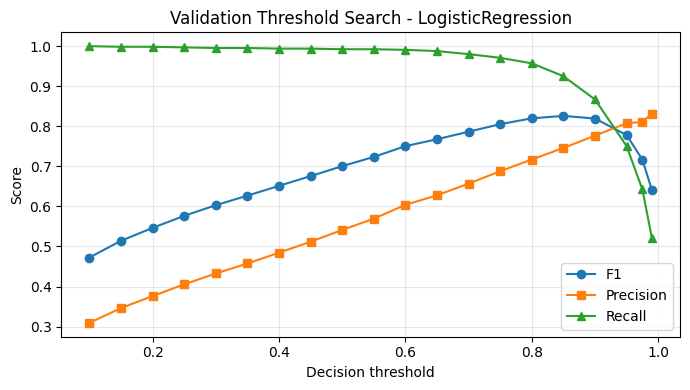

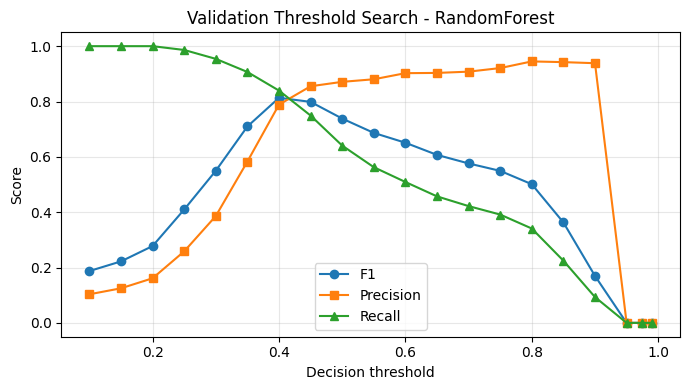

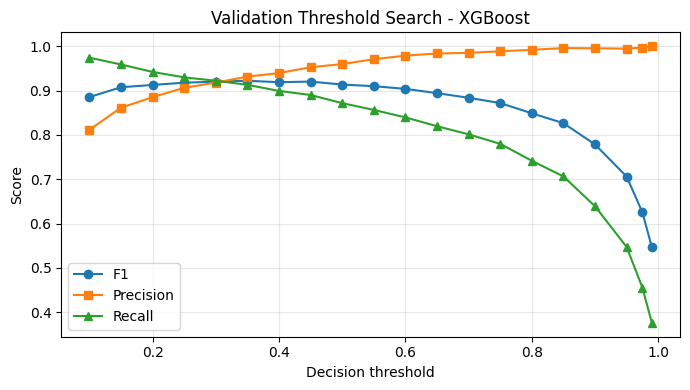

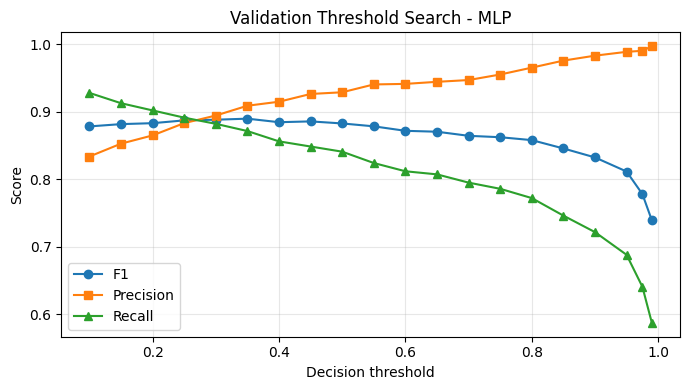

In [9]:
for model_name, threshold_df in threshold_tables.items():
    plt.figure(figsize=(7, 4))
    plt.plot(threshold_df["threshold"], threshold_df["f1"], marker="o", label="F1")
    plt.plot(threshold_df["threshold"], threshold_df["precision"], marker="s", label="Precision")
    plt.plot(threshold_df["threshold"], threshold_df["recall"], marker="^", label="Recall")
    plt.title(f"Validation Threshold Search - {model_name}")
    plt.xlabel("Decision threshold")
    plt.ylabel("Score")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    threshold_df.to_csv(results_dir / f"{model_name.lower()}_threshold_search.csv", index=False)

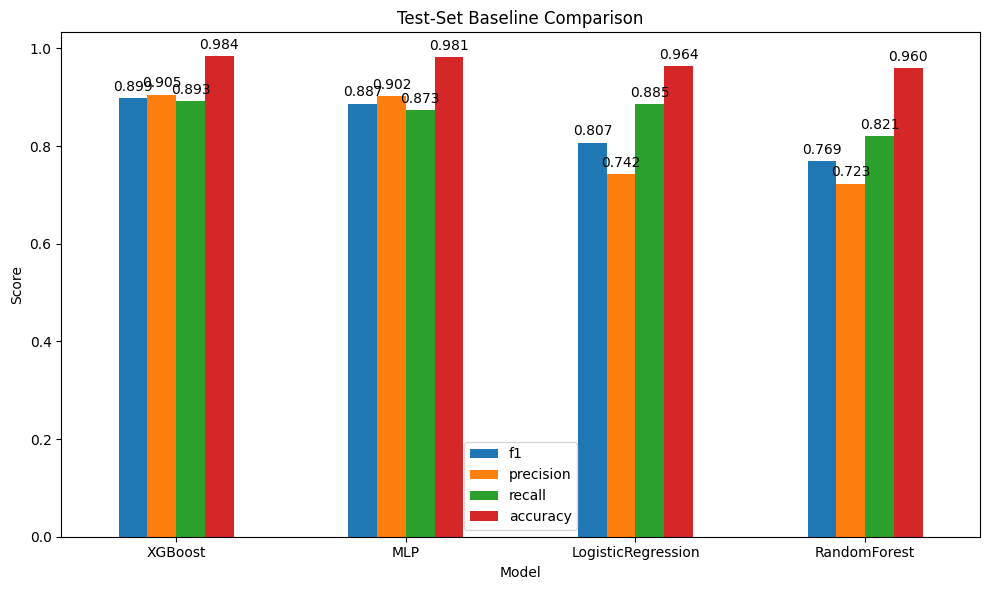

,model,accuracy,precision,recall,f1,macro_f1,samples_f1,best_threshold,threshold_strategy
0,XGBoost,0.9837,0.9053,0.8928,0.8990,0.0342,0.0718,0.35,global
1,MLP,0.9815,0.9019,0.8729,0.8872,0.0338,0.0702,0.35,global
2,LogisticRegression,0.9641,0.7420,0.8851,0.8073,0.0308,0.0665,0.85,global
3,RandomForest,0.9597,0.7233,0.8208,0.7690,0.0299,0.0623,1.00,per_target


,model,predicted_positive_rate,true_positive_rate
0,XGBoost,0.001073,0.001088
1,MLP,0.001053,0.001088
2,LogisticRegression,0.001298,0.001088
3,RandomForest,0.001235,0.001088


In [17]:
plot_metrics = ["f1", "precision", "recall", "accuracy"]
ax = results_df.set_index("model")[plot_metrics].plot(kind="bar", figsize=(10, 6))
ax.set_title("Test-Set Baseline Comparison")
ax.set_ylabel("Score")
ax.set_xlabel("Model")
plt.xticks(rotation=0)

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3)

plt.tight_layout()
plt.show()

summary_metric_columns = [
    "model",
    "accuracy",
    "precision",
    "recall",
    "f1",
    "macro_f1",
    "samples_f1",
    "best_threshold",
    "threshold_strategy",
]
metrics_summary_df = results_df[summary_metric_columns].copy()
numeric_metric_columns = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "macro_f1",
    "samples_f1",
    "best_threshold",
]
metrics_summary_df[numeric_metric_columns] = metrics_summary_df[numeric_metric_columns].round(4)
display(metrics_summary_df)

positive_rate_df = results_df[["model", "predicted_positive_rate", "true_positive_rate"]].copy()
positive_rate_df[["predicted_positive_rate", "true_positive_rate"]] = positive_rate_df[["predicted_positive_rate", "true_positive_rate"]].round(6)
display(positive_rate_df)

,feature,baseline_f1,perturbed_f1_mean,perturbed_f1_std,importance_drop
0,gen_status_0,0.908163,0.481621,0.017306,0.426542
1,pd_bus_8,0.908163,0.649205,0.011833,0.258958
2,pd_bus_6,0.908163,0.716424,0.012655,0.191739
3,branch_status_7,0.908163,0.786384,0.000947,0.121779
4,branch_status_21,0.908163,0.857159,0.003730,0.051004
5,branch_status_24,0.908163,0.872278,0.002746,0.035886
6,pd_bus_12,0.908163,0.874568,0.001894,0.033596
7,pd_bus_13,0.908163,0.885395,0.005255,0.022768
8,branch_status_8,0.908163,0.886442,0.004268,0.021721
9,pd_bus_39,0.908163,0.891546,0.003169,0.016617


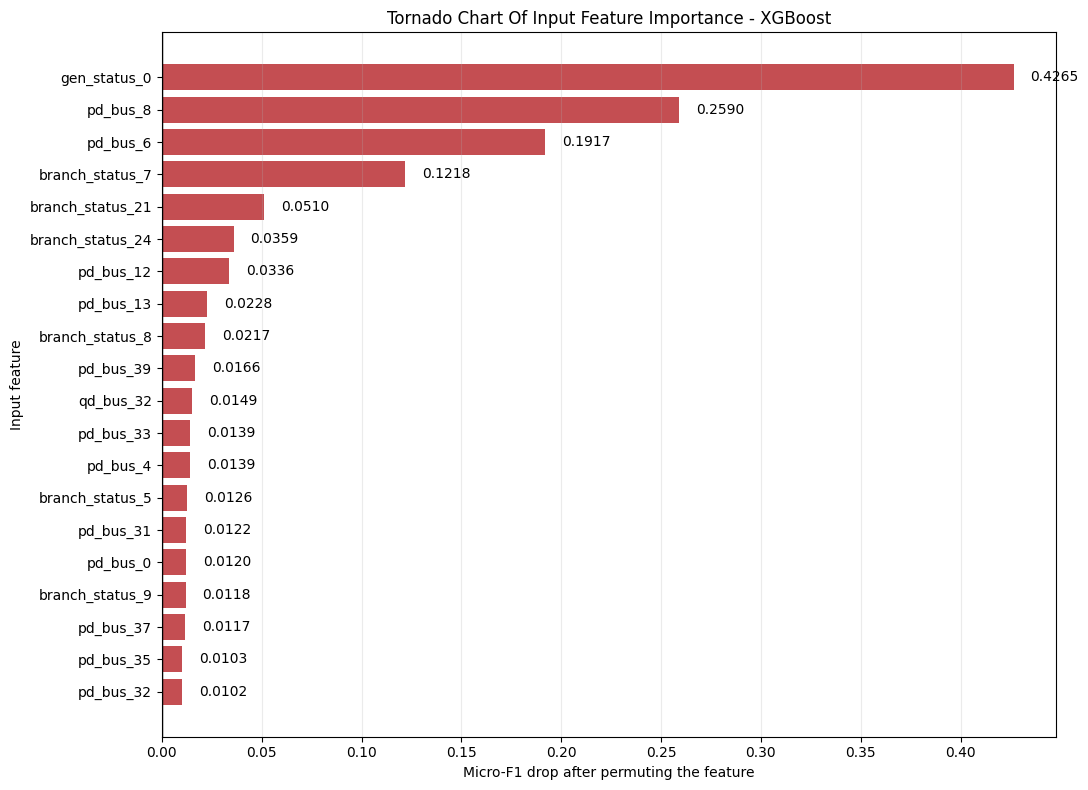

Computed permutation importance for XGBoost using 2,000 test samples.
Saved table to: c:\Users\i34005\OneDrive - Wood Mackenzie Limited\CSML\nodal-gnn\results\classical_ml_baselines\xgboost_tornado_feature_importance.csv


In [18]:
TOP_TORNADO_FEATURES = 15
PERMUTATION_SAMPLE = min(500, len(X_test))
PERMUTATION_REPEATS = 2

best_model_name = results_df.iloc[0]["model"]
best_model = fitted_models[best_model_name]


def get_native_feature_importance(model):
    estimator = model
    if hasattr(model, "named_steps") and "model" in model.named_steps:
        estimator = model.named_steps["model"]

    if hasattr(estimator, "estimators_"):
        tree_importances = [
            np.asarray(target_estimator.feature_importances_, dtype=np.float32)
            for target_estimator in estimator.estimators_
            if hasattr(target_estimator, "feature_importances_")
        ]
        if tree_importances:
            return np.mean(np.vstack(tree_importances), axis=0), "native_feature_importance"

        coefficient_importances = [
            np.abs(np.ravel(np.asarray(target_estimator.coef_, dtype=np.float32)))
            for target_estimator in estimator.estimators_
            if hasattr(target_estimator, "coef_")
        ]
        if coefficient_importances:
            return np.mean(np.vstack(coefficient_importances), axis=0), "mean_absolute_coefficient"

    if hasattr(estimator, "feature_importances_"):
        return np.asarray(estimator.feature_importances_, dtype=np.float32), "native_feature_importance"

    if hasattr(estimator, "coef_"):
        coefficients = np.asarray(estimator.coef_, dtype=np.float32)
        if coefficients.ndim == 1:
            return np.abs(coefficients), "absolute_coefficient"
        return np.mean(np.abs(coefficients), axis=0), "mean_absolute_coefficient"

    if hasattr(model, "estimators_"):
        coefficient_importances = [
            np.abs(np.ravel(np.asarray(target_estimator.coef_, dtype=np.float32)))
            for target_estimator in model.estimators_
            if target_estimator is not None and hasattr(target_estimator, "coef_")
        ]
        if coefficient_importances:
            return np.mean(np.vstack(coefficient_importances), axis=0), "mean_absolute_coefficient"

    return None, None


importance_values, importance_method = get_native_feature_importance(best_model)

if importance_values is None:
    val_scores = get_probability_scores(best_model, X_val)
    if best_model_name == "RandomForest":
        decision_threshold, _ = find_best_thresholds_per_target(y_val, val_scores, THRESHOLD_GRID)
    else:
        decision_threshold, _ = find_best_threshold(y_val, val_scores, THRESHOLD_GRID)

    if PERMUTATION_SAMPLE < len(X_test):
        sample_index = X_test.sample(n=PERMUTATION_SAMPLE, random_state=RANDOM_SEED).index
    else:
        sample_index = X_test.index

    X_importance = X_test.loc[sample_index].copy()
    y_importance = y_test.loc[sample_index].copy()
    baseline_scores = get_probability_scores(best_model, X_importance)
    baseline_predictions = (baseline_scores >= decision_threshold).astype(int)
    baseline_f1 = f1_score(y_importance, baseline_predictions, average="micro", zero_division=0)

    importance_rows = []
    rng = np.random.default_rng(RANDOM_SEED)

    for feature_index, feature_name in enumerate(feature_columns, start=1):
        perturbed_f1_scores = []
        for _ in range(PERMUTATION_REPEATS):
            X_perturbed = X_importance.copy()
            X_perturbed[feature_name] = rng.permutation(X_perturbed[feature_name].to_numpy())
            perturbed_scores = get_probability_scores(best_model, X_perturbed)
            perturbed_predictions = (perturbed_scores >= decision_threshold).astype(int)
            perturbed_f1_scores.append(
                f1_score(y_importance, perturbed_predictions, average="micro", zero_division=0)
            )

        perturbed_f1_mean = float(np.mean(perturbed_f1_scores))
        importance_rows.append({
            "feature": feature_name,
            "importance_value": baseline_f1 - perturbed_f1_mean,
        })

    importance_df = pd.DataFrame(importance_rows).sort_values("importance_value", ascending=False).reset_index(drop=True)
    importance_method = "permutation_micro_f1_drop"
else:
    importance_df = pd.DataFrame({
        "feature": feature_columns,
        "importance_value": np.asarray(importance_values, dtype=np.float32),
    }).sort_values("importance_value", ascending=False).reset_index(drop=True)

importance_df["model"] = best_model_name
importance_df["importance_method"] = importance_method
importance_df.to_csv(results_dir / f"{best_model_name.lower()}_tornado_feature_importance.csv", index=False)
display(importance_df.head(TOP_TORNADO_FEATURES))

plot_df = importance_df.head(TOP_TORNADO_FEATURES).sort_values("importance_value")
label_offset = max(plot_df["importance_value"].max() * 0.03, 1e-4)
colors = np.where(plot_df["importance_value"] >= 0.0, "#c44e52", "#4c72b0")

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(plot_df["feature"], plot_df["importance_value"], color=colors)
ax.axvline(0.0, color="black", linewidth=1)
ax.set_title(f"Tornado Chart Of Input Feature Importance - {best_model_name}")
ax.set_xlabel(f"Importance ({importance_method})")
ax.set_ylabel("Input feature")
ax.grid(axis="x", alpha=0.25)

for index, value in enumerate(plot_df["importance_value"]):
    horizontal_alignment = "left" if value >= 0.0 else "right"
    text_x = value + label_offset if value >= 0.0 else value - label_offset
    ax.text(text_x, index, f"{value:.4f}", va="center", ha=horizontal_alignment)

plt.tight_layout()
plt.show()

print(f"Computed feature importance for {best_model_name} using: {importance_method}")
print(f"Saved table to: {results_dir / f'{best_model_name.lower()}_tornado_feature_importance.csv'}")

,line,f1,true_positive_rate,model
7,cong_branch_7,0.916540,0.042933,LogisticRegression
6,cong_branch_6,0.909953,0.012800,LogisticRegression
10,cong_branch_10,0.640569,0.031333,LogisticRegression
0,cong_branch_0,0.000000,0.000000,LogisticRegression
1,cong_branch_1,0.000000,0.000000,LogisticRegression
2,cong_branch_2,0.000000,0.000000,LogisticRegression
3,cong_branch_3,0.000000,0.000000,LogisticRegression
4,cong_branch_4,0.000000,0.000000,LogisticRegression
5,cong_branch_5,0.000000,0.000000,LogisticRegression
8,cong_branch_8,0.000000,0.000000,LogisticRegression


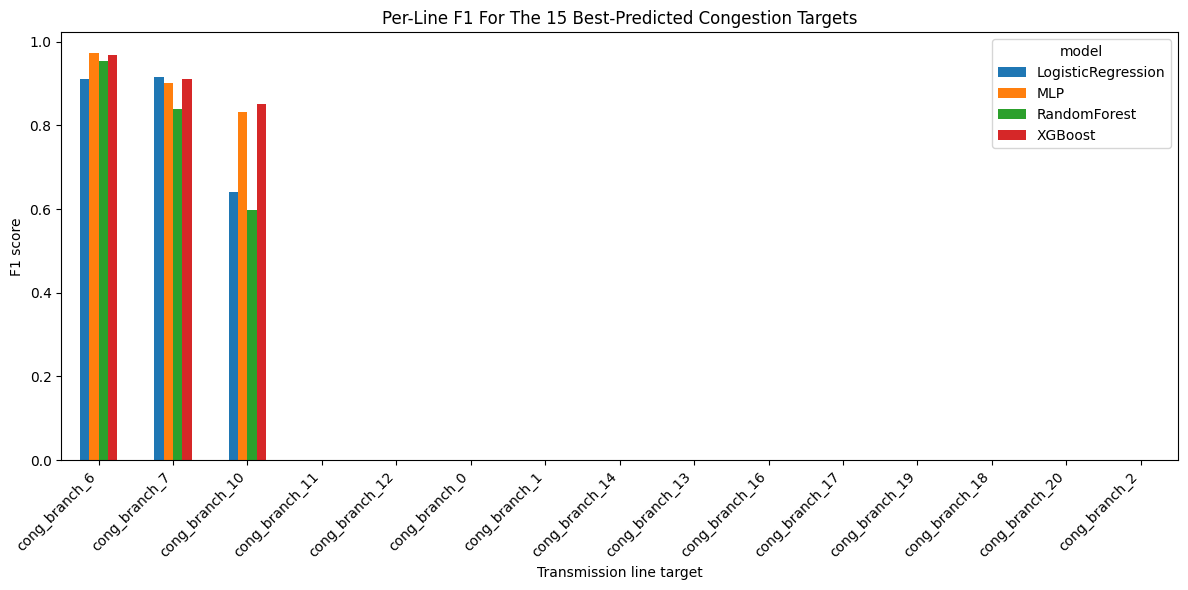

In [11]:
per_line_results = []

for model_name, predictions in test_predictions.items():
    line_f1 = f1_score(y_test, predictions, average=None, zero_division=0)
    per_line_df = pd.DataFrame({
        "line": target_columns,
        "f1": line_f1,
        "true_positive_rate": y_test.mean(axis=0).values,
        "model": model_name,
    })
    per_line_results.append(per_line_df)

per_line_results_df = pd.concat(per_line_results, ignore_index=True)
per_line_results_df.to_csv(results_dir / "per_line_f1_results.csv", index=False)
display(per_line_results_df.sort_values(["model", "f1"], ascending=[True, False]).head(20))

top_lines = (
    per_line_results_df.groupby("line")["f1"].mean().sort_values(ascending=False).head(15).index.tolist()
)
plot_df = per_line_results_df[per_line_results_df["line"].isin(top_lines)].copy()
pivot_df = plot_df.pivot(index="line", columns="model", values="f1").fillna(0.0)
pivot_df = pivot_df.loc[pivot_df.mean(axis=1).sort_values(ascending=False).index]

ax = pivot_df.plot(kind="bar", figsize=(12, 6))
ax.set_title("Per-Line F1 For The 15 Best-Predicted Congestion Targets")
ax.set_ylabel("F1 score")
ax.set_xlabel("Transmission line target")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Notes
- Logistic regression and MLP use standardized inputs, while random forest and XGBoost are trained on the raw tabular features.
- The dataset is multi-label and strongly imbalanced, so micro and macro F1 are more informative than subset accuracy alone.
- Set `MAX_SAMPLES = None` in cell 4 if you want to train on the full CSV.
- All trained baseline artifacts and result tables are saved under `results/classical_ml_baselines`.